# 04 — Equipment performance degradation agent

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/AI/community_agent_demos/04_equipment_performance_degradation_agent.ipynb)

Estimate compressor efficiency and exchanger conductance from measurements, then separate fouling from sensor symptoms.

This is a **synthetic public demonstration**, not an autonomous-control
system. The agent prepares a traceable engineering screening package;
a qualified engineer owns assumptions, validation, and decisions.


## Agent contract

**Inputs:** suction/discharge states, flow, power, temperatures, and
equipment reference curves. **Outputs:** reconciled performance
indicators, trend alarms, likely degradation mode, and maintenance
checks.

Compressor efficiency is $\eta=w_s/w$ and exchanger conductance is
inferred from $T_o=T_c+(T_i-T_c)e^{-UA/(\dot m C_p)}$.

Deep dive: [operations asset management](../../operations/operations_asset_management_with_neqsim.ipynb).


In [1]:
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path
import hashlib
import os
import platform
import subprocess
import sys


REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
    "numpy": "2.5.2",
    "pandas": "3.0.5",
    "matplotlib": "3.11.1",
    "scipy": "1.18.0",
}
install_specs = []
for package_name, required_version in REQUIRED_PACKAGES.items():
    try:
        installed_version = version(package_name)
    except PackageNotFoundError:
        installed_version = None
    if installed_version != required_version:
        install_specs.append(f"{package_name}=={required_version}")

if install_specs:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "--no-cache-dir",
            *install_specs,
        ],
        check=True,
    )

NEQSIM_SOURCE_REF = "master"
NEQSIM_SOURCE_REPOSITORY = "https://github.com/equinor/neqsim.git"
SOURCE_ROOT = Path(
    os.environ.get("NEQSIM_SOURCE_ROOT", "/content/neqsim-main")
).resolve()
SOURCE_JAR_OVERRIDE = os.environ.get("NEQSIM_SOURCE_JAR")
RUNTIME_DEPENDENCY_JAR = os.environ.get("NEQSIM_RUNTIME_DEPENDENCY_JAR")
using_local_source = "NEQSIM_SOURCE_ROOT" in os.environ

if not (SOURCE_ROOT / ".git").is_dir():
    subprocess.run(
        [
            "git",
            "clone",
            "--quiet",
            "--depth",
            "1",
            "--branch",
            NEQSIM_SOURCE_REF,
            NEQSIM_SOURCE_REPOSITORY,
            str(SOURCE_ROOT),
        ],
        check=True,
    )
elif not using_local_source:
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "fetch",
            "--quiet",
            "--depth",
            "1",
            "origin",
            NEQSIM_SOURCE_REF,
        ],
        check=True,
    )
    subprocess.run(
        [
            "git",
            "-C",
            str(SOURCE_ROOT),
            "checkout",
            "--quiet",
            "--detach",
            "FETCH_HEAD",
        ],
        check=True,
    )

NEQSIM_SOURCE_COMMIT = subprocess.check_output(
    ["git", "-C", str(SOURCE_ROOT), "rev-parse", "HEAD"],
    text=True,
).strip()

if SOURCE_JAR_OVERRIDE:
    SOURCE_JAR = Path(SOURCE_JAR_OVERRIDE).resolve()
    SOURCE_BUILD_KIND = os.environ.get(
        "NEQSIM_SOURCE_BUILD_KIND", "prebuilt source JAR override"
    )
else:
    jar_candidates = [
        path
        for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
        if not any(
            marker in path.name
            for marker in ("sources", "javadoc", "tests", "original")
        )
    ]
    if not jar_candidates:
        subprocess.run(
            [
                str(SOURCE_ROOT / "mvnw"),
                "-q",
                "-DskipTests",
                "-Dmaven.javadoc.skip=true",
                "package",
            ],
            cwd=SOURCE_ROOT,
            check=True,
        )
        jar_candidates = [
            path
            for path in (SOURCE_ROOT / "target").glob("neqsim-*.jar")
            if not any(
                marker in path.name
                for marker in ("sources", "javadoc", "tests", "original")
            )
        ]
    if not jar_candidates:
        raise FileNotFoundError(
            "The NeqSim master source build did not produce a runtime JAR."
        )
    SOURCE_JAR = sorted(jar_candidates, key=lambda path: len(path.name))[0]
    SOURCE_BUILD_KIND = "Maven package from current master"

SOURCE_JAR_SHA256 = hashlib.sha256(SOURCE_JAR.read_bytes()).hexdigest()
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim-agent-demo-matplotlib")

import jpype


if jpype.isJVMStarted():
    raise RuntimeError(
        "The JVM started before the NeqSim master JAR was selected. "
        "Restart the runtime and run all cells."
    )

jpype.addClassPath(str(SOURCE_JAR))
if RUNTIME_DEPENDENCY_JAR:
    jpype.addClassPath(str(Path(RUNTIME_DEPENDENCY_JAR).resolve()))
from neqsim.neqsimpython import init_jvm


init_jvm()
SOURCE_PROBE = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
DESIGN_PROBE = jpype.JClass(
    "neqsim.process.engineering.design.EngineeringDesignLoop"
)
LOADED_JAR_LOCATION = str(
    SOURCE_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
DESIGN_JAR_LOCATION = str(
    DESIGN_PROBE.class_.getProtectionDomain().getCodeSource().getLocation()
)
assert SOURCE_JAR.name in LOADED_JAR_LOCATION
assert SOURCE_JAR.name in DESIGN_JAR_LOCATION

print(f"NeqSim Python bridge: {version('neqsim')}")
print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_SOURCE_COMMIT}")
print(f"NeqSim source JAR SHA-256: {SOURCE_JAR_SHA256}")
print(f"Source build: {SOURCE_BUILD_KIND}")
print(f"Loaded thermodynamics from: {LOADED_JAR_LOCATION}")
print(f"Python runtime: {platform.python_version()}")


NeqSim Python bridge: 3.17.0
NeqSim source ref: master
NeqSim source commit: 1dee5b51f6689d0b383e8d90fece9729132dd6e3
NeqSim source JAR SHA-256: f3e4080d8e6a97225047de1ec04c5a7fcd1049845b770a11da4986d96d2dce8c
Source build: javac source overlay from exact master Java sources
Loaded thermodynamics from: file:/workspace/scratch/6d0c0fad8be4/neqsim-master/target/neqsim-current-master-agent-demo-complete.jar
Python runtime: 3.12.13


In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import optimize
from IPython.display import display
from neqsim.thermo import TPflash, fluid


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})
RNG = np.random.default_rng(42)


def flash_state(composition, pressure_bara, temperature_c, model="srk"):
    """Return a compact, unit-labelled NeqSim flash result."""
    system = fluid(model)
    for component, fraction in composition.items():
        system.addComponent(component, float(fraction))
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    system.setPressure(float(pressure_bara), "bara")
    system.setTemperature(float(temperature_c), "C")
    TPflash(system)
    system.initProperties()
    phases = []
    for phase_index in range(system.getNumberOfPhases()):
        phase = system.getPhase(phase_index)
        phases.append(
            {
                "phase": str(phase.getPhaseTypeName()),
                "beta_mol": float(phase.getBeta()),
                "density_kg_m3": float(phase.getDensity("kg/m3")),
            }
        )
    return {
        "system": system,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "density_kg_m3": float(system.getDensity("kg/m3")),
        "viscosity_pa_s": float(system.getViscosity("kg/msec")),
        "z_factor": float(system.getZ()),
        "molar_mass_kg_mol": float(system.getMolarMass("kg/mol")),
        "cp_j_kg_k": float(system.getCp("J/kgK")),
        "cv_j_kg_k": float(system.getCv("J/kgK")),
        "phases": phases,
    }


NORTHSTAR_GAS = {
    "methane": 0.820,
    "ethane": 0.075,
    "propane": 0.035,
    "i-butane": 0.010,
    "n-butane": 0.015,
    "n-heptane": 0.020,
    "CO2": 0.015,
    "nitrogen": 0.010,
}


In [3]:
suction = flash_state(NORTHSTAR_GAS, 45.0, 25.0)
kappa = suction["cp_j_kg_k"] / suction["cv_j_kg_k"]
gas_constant = 8.314462618
pressure_ratio = 2.20
ideal_work = (
    suction["z_factor"]
    * gas_constant
    * (25.0 + 273.15)
    / suction["molar_mass_kg_mol"]
    * kappa
    / (kappa - 1.0)
    * (pressure_ratio ** ((kappa - 1.0) / kappa) - 1.0)
)
print(f"NeqSim-derived isentropic work proxy={ideal_work / 1000:.1f} kJ/kg")


NeqSim-derived isentropic work proxy=89.3 kJ/kg


In [4]:
day = np.arange(70)
mass_rate = 50.0 + 2.5 * np.sin(day / 6.0)
true_efficiency = 0.79 - 0.00125 * day
true_ua_w_k = 5.2e5 - 2.0e3 * day
measured_power_mw = mass_rate * ideal_work / true_efficiency / 1e6
measured_power_mw += RNG.normal(0.0, 0.06, day.size)
inlet_c, coolant_c = 115.0, 25.0
outlet_c = coolant_c + (inlet_c - coolant_c) * np.exp(
    -true_ua_w_k / (mass_rate * suction["cp_j_kg_k"])
)
outlet_c += RNG.normal(0.0, 0.12, day.size)

inferred_efficiency = mass_rate * ideal_work / (measured_power_mw * 1e6)
inferred_ua = -mass_rate * suction["cp_j_kg_k"] * np.log(
    (outlet_c - coolant_c) / (inlet_c - coolant_c)
)
performance = pd.DataFrame(
    {
        "day": day,
        "efficiency": inferred_efficiency,
        "ua_mw_k": inferred_ua / 1e6,
        "power_mw": measured_power_mw,
        "outlet_c": outlet_c,
    }
)
performance["efficiency_7d"] = performance.efficiency.rolling(7).median()
performance["ua_7d"] = performance.ua_mw_k.rolling(7).median()
display(performance.tail())


,day,efficiency,ua_mw_k,power_mw,outlet_c,efficiency_7d,ua_7d
65,65,0.703164,0.394733,6.039114,27.897341,0.709507,0.399008
66,66,0.709977,0.386599,5.977033,28.102697,0.709977,0.395041
67,67,0.709523,0.382363,5.985445,28.227574,0.709523,0.394733
68,68,0.699039,0.375699,6.088600,28.444987,0.707108,0.393058
69,69,0.705083,0.370363,6.057962,28.649934,0.705083,0.386599


In [5]:
first = performance.iloc[:10]
last = performance.iloc[-10:]
indicators = pd.DataFrame(
    {
        "mode": ["compressor efficiency loss", "exchanger fouling", "temperature bias"],
        "severity": [
            (first.efficiency.mean() - last.efficiency.mean()) / 0.05,
            (first.ua_mw_k.mean() - last.ua_mw_k.mean()) / 0.10,
            abs(last.outlet_c.mean() - performance.outlet_c.iloc[-20:-10].mean()) / 3.0,
        ],
        "discriminating_check": [
            "verify power and anti-surge position",
            "inspect differential pressure and cleaning history",
            "compare redundant temperature element",
        ],
    }
).sort_values("severity", ascending=False)
display(indicators)


,mode,severity,discriminating_check
0,compressor efficiency loss,1.555198,verify power and anti-surge position
1,exchanger fouling,1.233793,inspect differential pressure and cleaning his...
2,temperature bias,0.024019,compare redundant temperature element


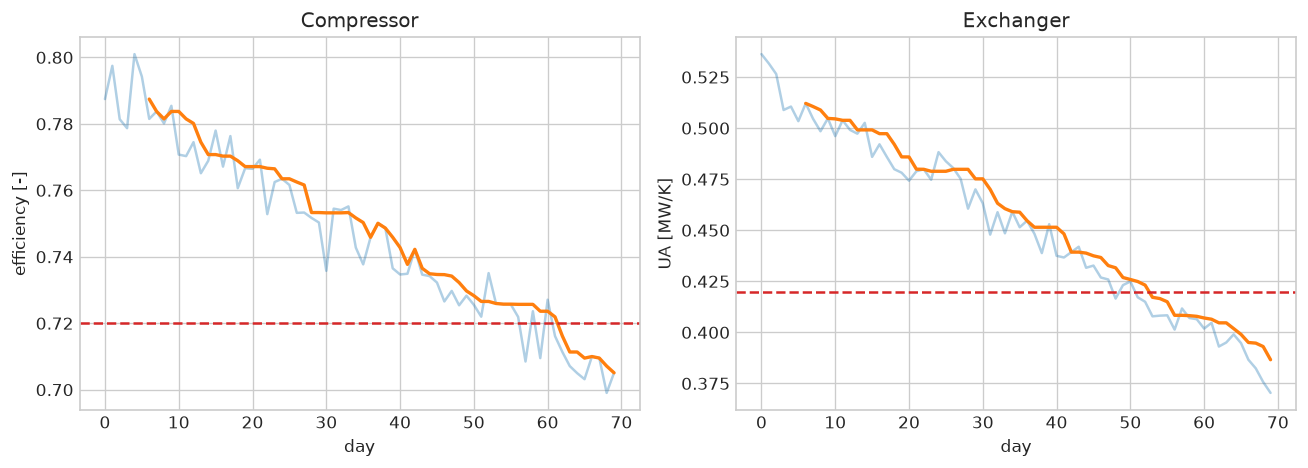

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(day, performance.efficiency, alpha=0.35)
axes[0].plot(day, performance.efficiency_7d, linewidth=2)
axes[0].axhline(0.72, color="tab:red", linestyle="--")
axes[0].set(xlabel="day", ylabel="efficiency [-]", title="Compressor")
axes[1].plot(day, performance.ua_mw_k, alpha=0.35)
axes[1].plot(day, performance.ua_7d, linewidth=2)
axes[1].axhline(0.42, color="tab:red", linestyle="--")
axes[1].set(xlabel="day", ylabel="UA [MW/K]", title="Exchanger")
plt.tight_layout()
plt.show()


In [7]:
assert last.efficiency.mean() < 0.72
assert last.ua_mw_k.mean() < 0.405
assert set(indicators.head(2)["mode"]) == {
    "compressor efficiency loss",
    "exchanger fouling",
}
print("VALIDATION PASSED")
print("Recommendation: verify instruments, then schedule compressor and exchanger checks.")


VALIDATION PASSED
Recommendation: verify instruments, then schedule compressor and exchanger checks.


## Interpretation and limits

Two slow degradations are visible and sensor bias is not the leading
explanation. The performance equations are simplified; use vendor
maps, calibrated heat loss, uncertainty bands, and reconciled
measurements for maintenance decisions.
